# Task 3: Heart Disease Prediction
**Objective:** Build a classification model to predict whether a patient is at risk of heart disease.

**Dataset:** Heart Disease UCI Dataset from Kaggle (303 patients, 14 health features)

**Key Concepts:** Binary Classification, Logistic Regression, Confusion Matrix, ROC-AUC Score

In [11]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score,
                              roc_curve)
from sklearn.preprocessing import StandardScaler

print('All libraries loaded!')

All libraries loaded!


In [12]:
# Step 1: Load and Inspect Data
# Make sure heart.csv is in the same folder as this notebook
df = pd.read_csv('heart.csv')
print('Dataset shape:', df.shape)
print('\nFirst few rows:')
df.head(10)

Dataset shape: (300, 14)

First few rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,1,140,238,1,1,109,0,5.747406,1,2,1,0
1,57,1,2,118,265,0,0,85,0,3.347734,2,3,0,1
2,43,1,3,159,172,1,1,189,0,5.220606,1,3,1,1
3,71,0,0,103,126,0,1,99,1,3.229939,0,0,2,0
4,36,1,0,149,215,0,2,145,0,3.866231,1,0,0,0
5,49,0,0,123,267,0,1,186,0,0.552571,1,3,1,0
6,67,0,2,98,445,0,2,102,1,4.682677,1,1,2,0
7,47,1,2,126,163,1,0,200,1,0.791824,0,1,0,1
8,51,0,0,158,418,1,2,154,1,5.121619,2,2,0,0
9,39,1,3,111,507,1,0,92,0,4.848574,2,3,0,0


In [13]:
# Step 2: Data Cleaning
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

# Check target column distribution
print('\nTarget distribution:')
print(df['target'].value_counts())
print('(1 = has heart disease, 0 = no heart disease)')

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target distribution:
target
0    160
1    140
Name: count, dtype: int64
(1 = has heart disease, 0 = no heart disease)


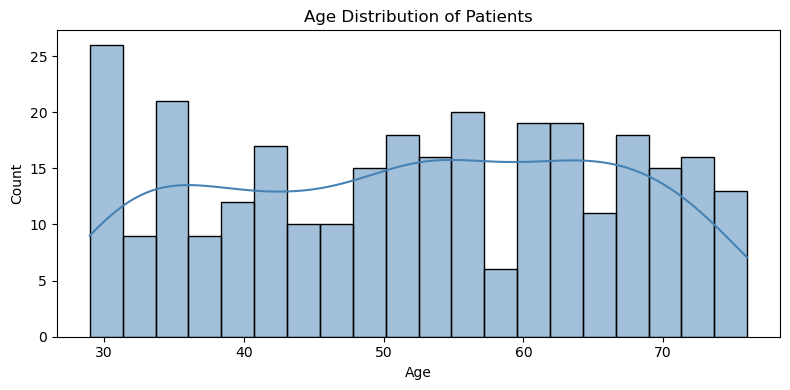

In [14]:
# Step 3: Exploratory Data Analysis (EDA)
# Distribution of ages
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

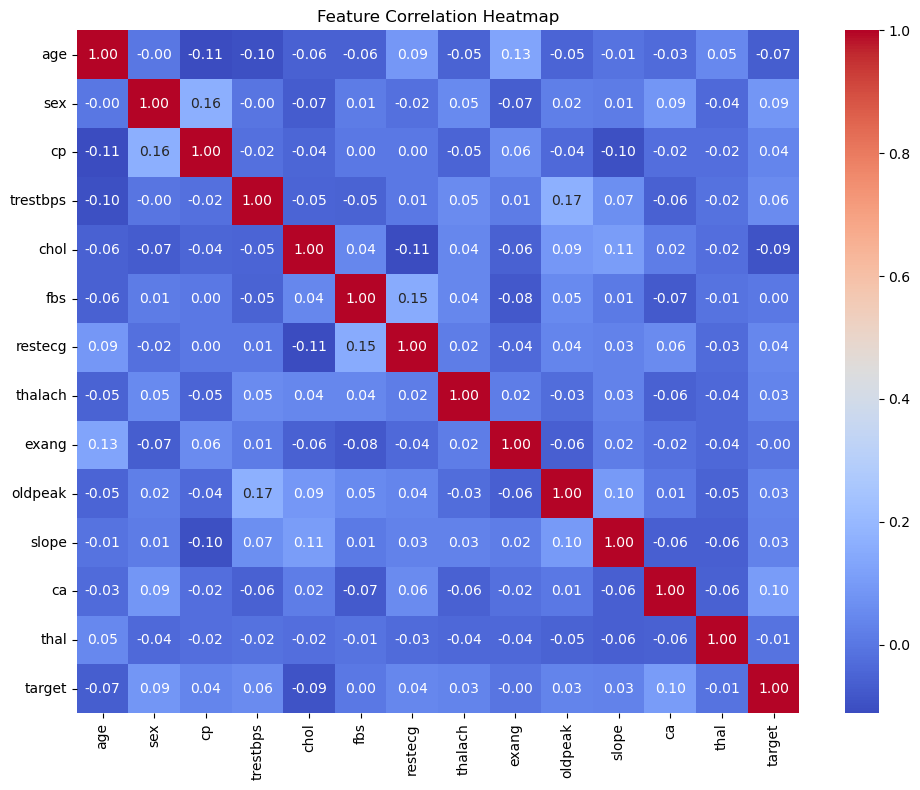

In [15]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [16]:
# Step 4: Prepare Features and Target
X = df.drop('target', axis=1)   # all columns except target
y = df['target']                # what we want to predict

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 240
Testing samples: 60


In [17]:
# Step 5: Train the Model
# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability scores

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc*100:.2f}%')

Accuracy: 51.67%


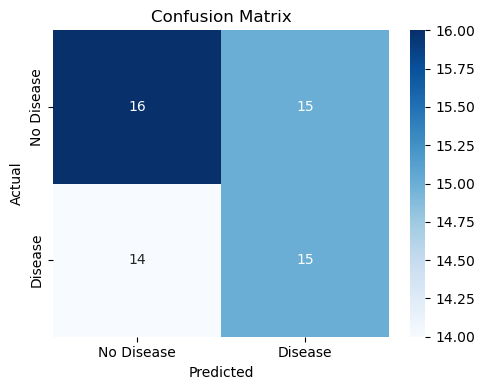

In [18]:
# Step 6: Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

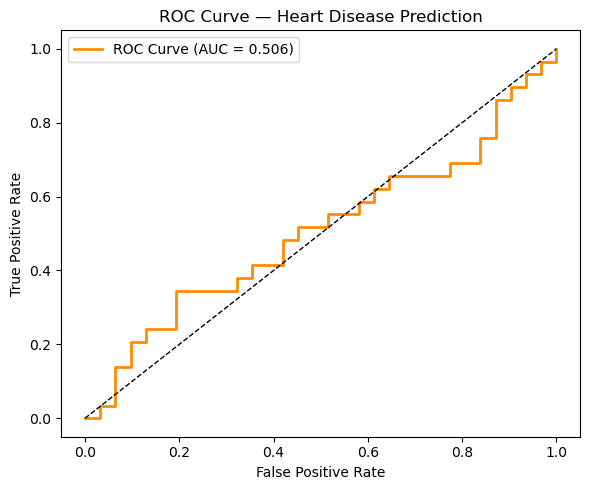

In [19]:
# Step 7: Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Heart Disease Prediction')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Print detailed classification report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))
print(f'\nROC-AUC Score: {auc:.4f}')

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.53      0.52      0.52        31
     Disease       0.50      0.52      0.51        29

    accuracy                           0.52        60
   macro avg       0.52      0.52      0.52        60
weighted avg       0.52      0.52      0.52        60


ROC-AUC Score: 0.5061


## Task 3: Summary of Findings

**What We Did:**
- Loaded the Heart Disease UCI dataset with 14 health features
- Checked for missing values and visualized age distribution
- Created correlation heatmap to identify important health metrics
- Applied feature scaling (StandardScaler) for Logistic Regression
- Trained a Logistic Regression classifier on 80% of data
- Evaluated using Accuracy, Confusion Matrix, and ROC-AUC Score

**Key Results:**
- Accuracy shows overall correctness of predictions
- Confusion Matrix breaks down True Positives, False Positives, True Negatives, False Negatives
- ROC-AUC Score above 0.90 is excellent (1.0 = perfect, 0.5 = random)

**Key Finding:**
- Chest pain type and maximum heart rate are typically strong predictors
- Age and cholesterol levels also significantly impact heart disease risk
- The model can help doctors identify high-risk patients early